# <font color="#1565C0"><b>Tutorial de NetworkX</b></font>

### <font color="#7B1FA2"><b>Modelación y resolución de problemas de redes con Python</b></font>

---

## <font color="#1565C0"><b>Introducción</b></font>

**NetworkX** es una biblioteca de Python que permite representar grafos y aplicar algoritmos sobre ellos. En este tutorial resolvemos tres problemas de optimización en redes:

| <font color="#1565C0"><b>Inciso</b></font> | <font color="#1565C0"><b>Problema</b></font> | <font color="#1565C0"><b>Objetivo</b></font> | <font color="#1565C0"><b>Red del ejercicio</b></font> |
|:---:|:---|:---|:---|
| **a** | **Árbol de expansión mínima** | Conectar todos los nodos con el menor costo total, sin ciclos. | `actividad_1_a.png`, considerada sin dirección. |
| **b** | **Ruta más corta** | Encontrar un recorrido de costo mínimo entre un origen y un destino. | `actividad_1_a.png`, respetando las direcciones. |
| **c** | **Flujo máximo** | Maximizar el flujo de una fuente a un sumidero, respetando capacidades. | `actividad_1_b.png`. |

En cada inciso seguimos las etapas de **modelación, resolución, representación y comprobación**. Explicamos los comandos de NetworkX y la sintaxis de Python conforme los utilizamos.

> <font color="#00838F"><b>Principio de modelación:</b></font> la solución depende de los <u>nodos, conexiones, direcciones y atributos numéricos</u> de la red. La disposición gráfica permite comunicar esa estructura.

## <font color="#1565C0"><b>Preparación del entorno</b></font>

### <font color="#00838F"><b>Bibliotecas utilizadas</b></font>

| <font color="#1565C0"><b>Biblioteca</b></font> | <font color="#1565C0"><b>Abreviatura</b></font> | <font color="#1565C0"><b>Función en el tutorial</b></font> |
|:---|:---:|:---|
| `networkx` | `nx` | Representar grafos y ejecutar algoritmos. |
| `matplotlib.pyplot` | `plt` | Mostrar las representaciones gráficas. |

Ejecutamos las celdas de código **en orden**, desde esta sección. Cada inciso utiliza un grafo y un diccionario de posiciones con nombres propios:

| <font color="#1565C0"><b>Inciso</b></font> | <font color="#1565C0"><b>Grafo</b></font> | <font color="#1565C0"><b>Posiciones</b></font> |
|:---:|:---|:---|
| **a** | `G_arbol` | `pos_arbol` |
| **b** | `G_rutas` | `pos_rutas` |
| **c** | `G_flujo` | `pos_flujo` |

Estos nombres permiten conservar las tres redes en memoria y volver a dibujarlas sin utilizar los datos de otro inciso.

Si necesitamos instalar las bibliotecas en Jupyter o Colab, podemos ejecutar en una celda de código:

```python
%pip install networkx matplotlib
```

La instrucción <font color="#1565C0"><b>import</b></font>
carga una biblioteca o módulo.

La palabra <font color="#1565C0"><b>as</b></font>
asigna un nombre abreviado. Por ejemplo, `nx.Graph()` accede
a la clase `Graph` de NetworkX mediante la abreviatura `nx`.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

---

## <font color="#1565C0"><b>1. Árbol de expansión mínima (inciso a)</b></font>

### <font color="#7B1FA2"><b>1.1. Planteamiento del problema</b></font>

Utilizamos la red de **actividad_1_a.png**, que se muestra a continuación. Para este inciso consideramos su **versión no dirigida**.

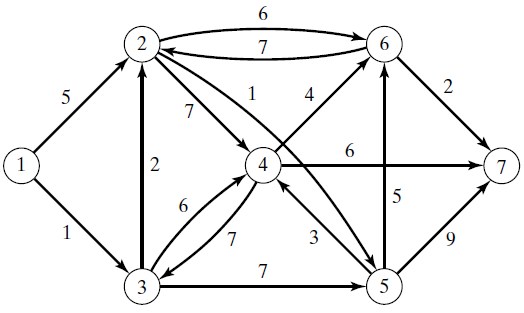

*<font color="#00838F"><b>Figura 1.</b> actividad_1_a.png: Red original con costos y sentidos de recorrido. Fuente: imagen del enunciado de la actividad, proporcionada como material del ejercicio.</font>*

#### <font color="#00838F"><b>Formulación</b></font>

Sea $G=(V,E)$ un <font color="#1565C0"><b>grafo no dirigido,
conexo y ponderado</b></font>, donde:

- $V$ es el conjunto de nodos.
- $E$ es el conjunto de aristas.
- $w_{ij}$ es el peso o costo de la arista $\{i,j\}$.

Un **árbol de expansión** es un subgrafo $T=(V,E_T)$
que conserva todos los nodos y satisface:

1. **Conectividad:** existe un camino entre cualquier par de nodos.
2. **Ausencia de ciclos:** el subgrafo no contiene ciclos.

Estas propiedades implican:

$$
|E_T|=|V|-1.
$$

El problema consiste en encontrar:

$$
T^\ast\in
\underset{T\text{ árbol de expansión de }G}{\operatorname{argmin}}
\sum_{\{i,j\}\in E_T}w_{ij}.
$$

> <font color="#2E7D32"><b>Objetivo:</b></font>
> minimizar <u>la suma de los costos de todas las aristas del árbol</u>.
> El árbol debe conectar <u>todos los nodos de la red</u>.

### <font color="#7B1FA2"><b>1.2. Construcción del grafo</b></font>

#### <font color="#00838F"><b>Tipo de grafo</b></font>

La instrucción <font color="#1565C0"><b>G_arbol = nx.Graph()</b></font>
crea un grafo no dirigido y lo asigna a la variable `G_arbol`.

En este modelo, $\{i,j\}$ y $\{j,i\}$ representan la misma arista.

#### <font color="#00838F"><b>Ingreso de las conexiones</b></font>

El método
<font color="#1565C0"><b>G_arbol.add_weighted_edges_from()</b></font>
recibe una colección de tuplas de la forma:

**(primer nodo, segundo nodo, peso)**

Por ejemplo, `(1, 2, 5)` incorpora la arista $\{1,2\}$
con peso $w_{12}=5$.

Los nodos se crean automáticamente cuando aparecen en una arista.
El tercer elemento de cada tupla se almacena en el atributo
<font color="#1565C0"><b>weight</b></font>.

#### <font color="#00838F"><b>Sintaxis de Python</b></font>

- Los corchetes `[...]` delimitan una **lista**.
- Los paréntesis `(1, 2, 5)` delimitan una **tupla**.
- El punto en `G_arbol.add_weighted_edges_from(...)` indica que
  utilizamos un **método del objeto G_arbol**.

#### <font color="#00838F"><b>Pesos de la versión no dirigida</b></font>

La imagen tiene costos distintos en los dos sentidos de algunas conexiones. Al construir un **grafo simple no dirigido**, debemos identificar qué peso queda registrado para cada arista:

| <font color="#1565C0"><b>Arista</b></font> | <font color="#1565C0"><b>Peso que conserva este bloque</b></font> | <font color="#1565C0"><b>Motivo</b></font> |
|:---:|:---:|:---|
| $\{2,6\}$ | **6** | Registramos `(2, 6, 6)` una sola vez. |
| $\{3,4\}$ | **7** | `(4, 3, 7)` actualiza la arista ingresada antes como `(3, 4, 6)`. |

> <font color="#C62828"><b>Lectura de los datos:</b></font> `Graph` guarda una sola arista por par de nodos. Al volver a agregarla, actualiza sus atributos; <u>no elige automáticamente el menor costo</u>. Estos son los pesos de la versión no dirigida utilizada en nuestro código.

In [2]:
G_arbol = nx.Graph()

G_arbol.add_weighted_edges_from([
    (1, 2, 5),
    (1, 3, 1),
    (2, 4, 7),
    (2, 5, 1),
    (2, 6, 6),
    (3, 2, 2),
    (3, 4, 6),
    (3, 5, 7),
    (4, 3, 7),
    (4, 6, 4),
    (4, 7, 6),
    (5, 4, 3),
    (5, 6, 5),
    (5, 7, 9),
    (6, 7, 2),
])

### <font color="#7B1FA2"><b>1.3. Representación gráfica de la red</b></font>

#### <font color="#00838F"><b>Cálculo de las posiciones</b></font>

La instrucción
<font color="#1565C0"><b>nx.spring_layout(G_arbol, seed=0)</b></font>
calcula una distribución de los nodos mediante un modelo
de fuerzas: los nodos se repelen y las conexiones ejercen atracción.

El resultado se guarda en **pos_arbol**, un diccionario que asocia
cada nodo con sus coordenadas de dibujo.

Por defecto, los pesos influyen en la intensidad de atracción entre nodos conectados; esto solo afecta al dibujo.

El argumento **seed=0** fija la semilla aleatoria utilizada
para iniciar el procedimiento. Esto permite reproducir el dibujo
en las mismas condiciones de ejecución.

#### <font color="#00838F"><b>Dibujo de nodos y conexiones</b></font>

La función <font color="#1565C0"><b>nx.draw()</b></font>
representa el grafo **G_arbol** utilizando las coordenadas **pos_arbol**.

| <font color="#1565C0"><b>Argumento</b></font> | <font color="#1565C0"><b>Significado</b></font> |
|:---|:---|
| `with_labels=True` | Mostrar los nombres de los nodos. |
| `node_color="purple"` | Establecer el color de los nodos. |
| `font_color="white"` | Establecer el color de sus etiquetas. |
| `node_size=800` | Controlar el tamaño visual de los nodos. |
| `arrows=True` | Utilizar un trazado que permite dibujar curvas. |
| `arrowstyle="-"` | Representar las aristas sin puntas de flecha. |
| `connectionstyle="arc3,rad=0.15"` | Establecer la curvatura de las aristas. |

El grafo se mantiene **no dirigido**: `arrows=True` permite utilizar curvas y **`arrowstyle="-"`** representa las conexiones sin flechas. La curvatura modifica únicamente su apariencia.

#### <font color="#00838F"><b>Obtención y dibujo de los pesos</b></font>

La instrucción
<font color="#1565C0"><b>nx.get_edge_attributes(G_arbol, "weight")</b></font>
devuelve un diccionario con los pesos de las aristas.

Lo guardamos en **pesos** y lo entregamos a
**nx.draw_networkx_edge_labels()** mediante el argumento
**edge_labels=pesos**. Utilizamos **`connectionstyle="arc3,rad=0.15"`** y **`node_size=800`** también en las etiquetas, para colocar cada peso sobre la curva correspondiente. **`rotate=False`** mantiene los números horizontales.

#### <font color="#00838F"><b>Resaltado de las etiquetas</b></font>

Utilizamos **texto blanco sobre fondo azul** para distinguir los pesos de las líneas del dibujo:

| <font color="#1565C0"><b>Argumento</b></font> | <font color="#1565C0"><b>Función</b></font> |
|:---|:---|
| `font_color="white"` | Establecer el color blanco del texto. |
| `bbox={...}` | Definir el recuadro que contiene cada etiqueta mediante un diccionario. |
| `"facecolor": "#1565C0"` | Dar color azul al fondo. |
| `"edgecolor": "none"` | Dibujar el recuadro sin borde. |
| `"boxstyle": "round,pad=0.3"` | Redondear sus esquinas y dejar espacio alrededor del texto. |

Aplicamos este formato a las etiquetas de los tres incisos.

Finalmente, **plt.show()** muestra la figura.

> <font color="#00838F"><b>Distinción esencial:</b></font>
> `spring_layout` calcula coordenadas para el dibujo.
> <u>No calcula el árbol mínimo ni modifica los costos almacenados</u>.
> Un cruce de líneas sin un nodo señalado no crea una nueva conexión.

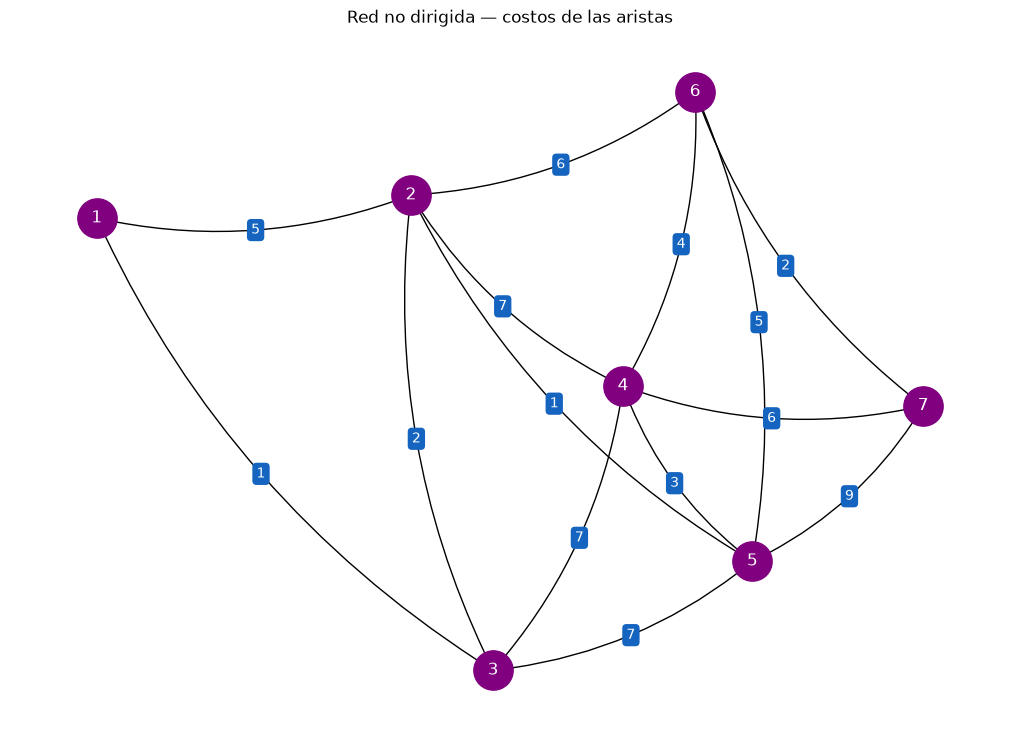

In [3]:
pos_arbol = nx.spring_layout(G_arbol, seed=0)

plt.figure(figsize=(10, 7))

nx.draw(
    G_arbol,
    pos_arbol,
    with_labels=True,
    node_color="purple",
    font_color="white",
    node_size=800,
    arrows=True,
    arrowstyle="-",
    connectionstyle="arc3,rad=0.15"
)

pesos = nx.get_edge_attributes(G_arbol, "weight")
nx.draw_networkx_edge_labels(
    G_arbol,
    pos_arbol,
    edge_labels=pesos,
    font_color="white",
    bbox={
        "facecolor": "#1565C0",
        "edgecolor": "none",
        "boxstyle": "round,pad=0.3"
    },
    node_size=800,
    connectionstyle="arc3,rad=0.15",
    rotate=False
)

plt.title("Red no dirigida — costos de las aristas")
plt.show()

### <font color="#7B1FA2"><b>1.4. Resolución mediante NetworkX</b></font>

#### <font color="#00838F"><b>Función utilizada</b></font>

Aplicamos
<font color="#1565C0"><b>nx.minimum_spanning_tree(G_arbol)</b></font>
y guardamos el resultado en **T**.

Esta función devuelve un nuevo grafo con las aristas seleccionadas.
Conserva sus atributos, incluidos los pesos.

Aunque no escribimos argumentos adicionales, los valores
predeterminados son:

| <font color="#1565C0"><b>Parámetro</b></font> | <font color="#1565C0"><b>Valor predeterminado</b></font> | <font color="#1565C0"><b>Interpretación</b></font> |
|:---|:---|:---|
| `weight` | `"weight"` | Atributo que contiene los costos. |
| `algorithm` | `"kruskal"` | Algoritmo utilizado para obtener el árbol. |

#### <font color="#00838F"><b>Fundamento del algoritmo de Kruskal</b></font>

Kruskal considera las aristas por costo creciente:

1. Selecciona una arista si une dos componentes distintas.
2. Descarta una arista si sus extremos ya están conectados,
   porque incorporarla formaría un ciclo.
3. Continúa hasta conectar todos los nodos.

En un grafo conexo con $n$ nodos, el resultado contiene
exactamente <font color="#2E7D32"><b>$n-1$ aristas</b></font>.

La selección se justifica mediante la **propiedad del corte**:
una arista de peso mínimo que cruza un corte puede formar parte
de algún árbol de expansión mínima.

> <font color="#C62828"><b>Condición de uso:</b></font>
> si el grafo no fuera conexo, la función devolvería un
> <u>bosque de expansión mínima</u>, con un árbol por componente.
> En este ejercicio, la red es conexa.

In [4]:
T = nx.minimum_spanning_tree(G_arbol)

### <font color="#7B1FA2"><b>1.5. Representación de la solución sobre la red</b></font>

#### <font color="#00838F"><b>Relación entre la red y el árbol mínimo</b></font>

El árbol obtenido es un <font color="#1565C0"><b>subgrafo</b></font>
de la red original: conserva todos sus nodos y selecciona
una parte de sus aristas.

Si $G=(V,E)$ es la red y $T=(V,E_T)$ es el árbol, entonces:

$$
E_T\subseteq E,
\qquad
|E_T|=|V|-1.
$$

En este ejercicio, el árbol contiene **6 aristas** que conectan
los **7 nodos**, <u>sin formar ciclos</u>.

#### <font color="#00838F"><b>Dibujo de la red completa</b></font>

Primero dibujamos **G_arbol** con sus conexiones en
<font color="#757575"><b>gris</b></font>.

Utilizamos las posiciones **pos_arbol** calculadas anteriormente.
Esto permite conservar una misma distribución de los nodos
y comparar las conexiones disponibles con las seleccionadas.

#### <font color="#00838F"><b>Resaltado del árbol mínimo</b></font>

Después utilizamos
<font color="#1565C0"><b>nx.draw_networkx_edges()</b></font>
para dibujar las aristas de **T** sobre la red completa.

El argumento **edge_color="darkorange"** establece el color
<font color="#E65100"><b>naranja</b></font>,
mientras que **width=3** aumenta el grosor de las aristas seleccionadas.

En la red completa, el árbol y las etiquetas utilizamos la misma curvatura **`connectionstyle="arc3,rad=0.15"`** y el mismo **`node_size=1000`**. Las aristas del árbol quedan superpuestas a sus curvas originales, conservando **`arrowstyle="-"`** para mostrarlas sin flechas.

Finalmente, mostramos los pesos de **G_arbol**, de modo que la figura
conserve los costos de todas las conexiones.

| <font color="#1565C0"><b>Elemento visual</b></font> | <font color="#1565C0"><b>Interpretación</b></font> |
|:---|:---|
| <font color="purple"><b>Nodos morados</b></font> | Nodos de la red. |
| <font color="#757575"><b>Aristas grises</b></font> | Conexiones disponibles que no pertenecen al árbol obtenido. |
| <font color="darkorange"><b>Aristas naranjas</b></font> | Conexiones seleccionadas por el algoritmo. |
| <font color="#1565C0"><b>Etiquetas azules con texto blanco</b></font> | Costos de las aristas. |

> <font color="#2E7D32"><b>Lectura de la solución:</b></font>
> las aristas naranjas forman el árbol de expansión mínima.
> Su costo es la suma de los pesos de <u>esas aristas</u>,
> no de todas las conexiones mostradas.

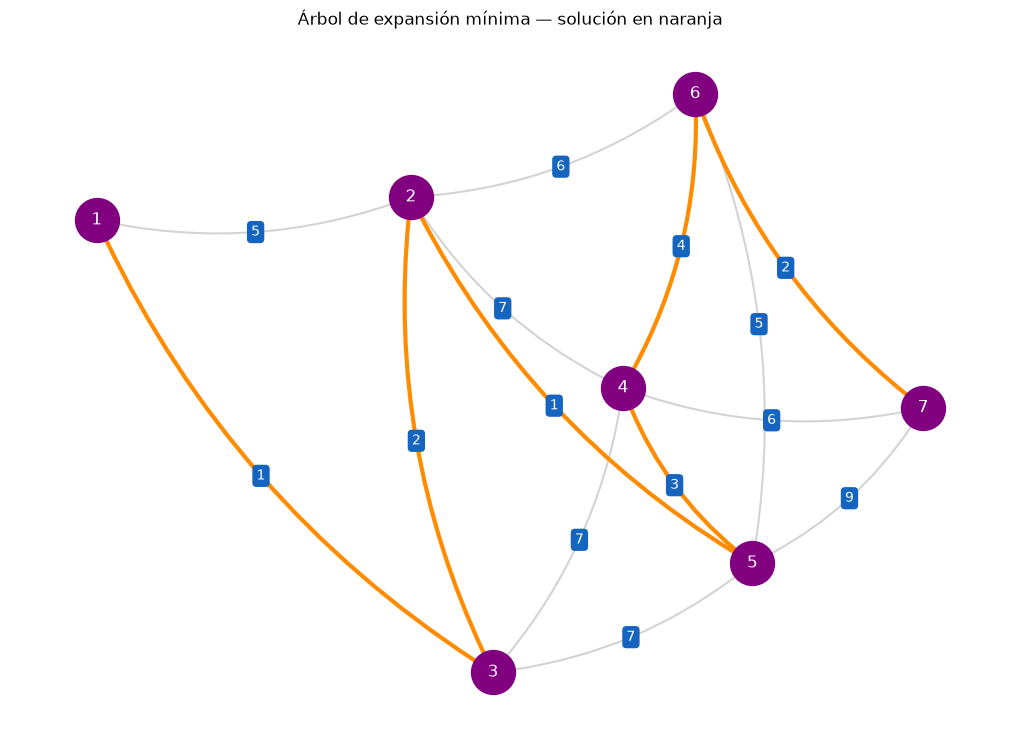

In [5]:
plt.figure(figsize=(10, 7))

# Dibujamos la red completa con aristas curvas, sin flechas.
nx.draw(
    G_arbol,
    pos_arbol,
    with_labels=True,
    node_color="purple",
    font_color="white",
    node_size=1000,
    edge_color="lightgray",
    width=1.5,
    arrows=True,
    arrowstyle="-",
    connectionstyle="arc3,rad=0.15"
)

# Resaltamos las aristas del árbol mínimo con la misma curvatura.
nx.draw_networkx_edges(
    T,
    pos_arbol,
    edge_color="darkorange",
    width=3,
    node_size=1000,
    arrows=True,
    arrowstyle="-",
    connectionstyle="arc3,rad=0.15"
)

# Mostramos los costos sobre las curvas de toda la red.
pesos = nx.get_edge_attributes(G_arbol, "weight")

nx.draw_networkx_edge_labels(
    G_arbol,
    pos_arbol,
    edge_labels=pesos,
    font_color="white",
    bbox={
        "facecolor": "#1565C0",
        "edgecolor": "none",
        "boxstyle": "round,pad=0.3"
    },
    node_size=1000,
    connectionstyle="arc3,rad=0.15",
    rotate=False
)

plt.title("Árbol de expansión mínima — solución en naranja")
plt.show()

### <font color="#7B1FA2"><b>1.6. Resultado y comprobación matemática</b></font>

Al indicar **`weight="weight"`**, **`T.size()`** suma los pesos de las aristas del árbol. Guardamos ese valor en `costo_total` y lo mostramos con `print()`.

In [6]:
costo_total = T.size(weight="weight")
print("Costo total del árbol de expansión mínima:", costo_total)

Costo total del árbol de expansión mínima: 13.0


#### <font color="#00838F"><b>Aristas seleccionadas</b></font>

El árbol obtenido contiene las siguientes conexiones:

| <font color="#1565C0"><b>Arista</b></font> | <font color="#1565C0"><b>Costo</b></font> |
|:---:|---:|
| $\{1,3\}$ | 1 |
| $\{2,5\}$ | 1 |
| $\{2,3\}$ | 2 |
| $\{6,7\}$ | 2 |
| $\{4,5\}$ | 3 |
| $\{4,6\}$ | 4 |

Su costo total es:

$$
C(T)=1+1+2+2+3+4=\boxed{13}.
$$

#### <font color="#00838F"><b>Comprobación de la estructura</b></font>

La red tiene **7 nodos** y el árbol contiene **6 aristas**:

$$
|E_T|=6=7-1.
$$

Las conexiones seleccionadas permiten recorrer la secuencia:

$$
1-3-2-5-4-6-7.
$$

Esta secuencia conecta todos los nodos y no forma ciclos.
Por tanto, el subgrafo es un **árbol de expansión**.

#### <font color="#00838F"><b>Comprobación de optimalidad</b></font>

Todo árbol de expansión de esta red debe seleccionar
exactamente **seis aristas**.

Los seis menores costos presentes en el grafo construido son:

$$
1,\;1,\;2,\;2,\;3,\;4.
$$

Por consiguiente, cualquier árbol de expansión $T'$ satisface:

$$
C(T')\geq 1+1+2+2+3+4=13.
$$

El árbol obtenido alcanza esa cota:

$$
C(T)=13.
$$

Así, su costo es mínimo. Además, estas son las únicas seis aristas con peso menor o igual que 4; cualquier sustitución aumentaría el costo. Por ello, <u>el árbol mínimo de este ejemplo es único</u>.

> <font color="#2E7D32"><b>Solución final:</b></font>
> el árbol de expansión mínima conecta los siete nodos
> mediante seis aristas, <u>sin ciclos</u>,
> con un <b>costo total de 13 unidades</b>.

> <font color="#00838F"><b>Relación con la imagen:</b></font> el resultado corresponde a los pesos registrados en **1.2**. Si conserváramos el menor costo de cada conexión con sentidos opuestos, $\{3,4\}$ tendría peso 6; el árbol y su costo mínimo seguirían siendo los mismos, porque esa arista no pertenece a las seis de menor costo.

### <font color="#7B1FA2"><b>1.7. Documentación de los comandos</b></font>

| <font color="#1565C0"><b>Comando</b></font> | <font color="#1565C0"><b>Función</b></font> |
|:---|:---|
| `nx.Graph()` | Crear un grafo no dirigido. |
| `G_arbol.add_weighted_edges_from()` | Agregar aristas con pesos. |
| `nx.spring_layout()` | Calcular posiciones para el dibujo. |
| `nx.draw()` | Dibujar nodos y conexiones. |
| `nx.get_edge_attributes()` | Consultar un atributo de las aristas. |
| `nx.draw_networkx_edge_labels()` | Dibujar etiquetas sobre las aristas. |
| `nx.draw_networkx_edges(T, pos_arbol, ...)` | Resaltar las aristas del árbol usando las mismas posiciones. |
| `nx.minimum_spanning_tree()` | Obtener un árbol o bosque de expansión mínima. |
| `T.size(weight="weight")` | Sumar los pesos de las aristas del árbol. |
| `plt.figure(figsize=(10, 7))` | Crear una figura de 10 por 7 pulgadas. |
| `plt.title()` | Asignar un título a la figura. |
| `arrows=True`, `arrowstyle="-"`, `connectionstyle="arc3,rad=0.15"` | Dibujar aristas curvas sin flechas. |
| `font_color="white"`, `bbox={...}` | Resaltar las etiquetas con texto blanco y recuadro azul. |
| `plt.show()` | Mostrar la figura. |

#### <font color="#00838F"><b>Documentación oficial</b></font>

- [Grafos no dirigidos: Graph](https://networkx.org/documentation/stable/reference/classes/graph.html)
- [Ingreso de aristas ponderadas](https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.add_weighted_edges_from.html)
- [Árbol de expansión mínima](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.tree.mst.minimum_spanning_tree.html)
- [Funciones de representación gráfica](https://networkx.org/documentation/stable/reference/drawing.html)
- [Dibujo de aristas y opciones de curvatura](https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw_networkx_edges.html)
- [Etiquetas sobre las aristas](https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw_networkx_edge_labels.html)

---

## <font color="#1565C0"><b>2. Ruta más corta (inciso b)</b></font>

### <font color="#7B1FA2"><b>2.1. Planteamiento del problema</b></font>

Retomamos la red de **actividad_1_a.png**, mostrada en la **figura 1**.

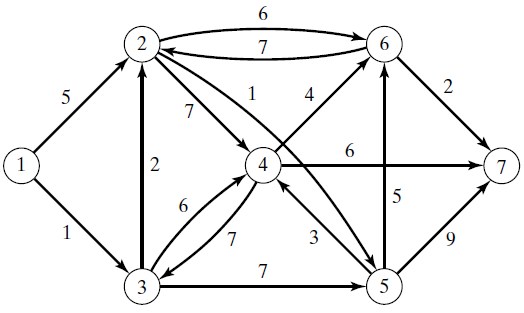

*<font color="#00838F"><b>Figura 1 (referencia del inciso b).</b> actividad_1_a.png: Red original con costos y sentidos de recorrido. Fuente: imagen del enunciado de la actividad, proporcionada como material del ejercicio.</font>*

Ahora buscamos la ruta que conecta el nodo **1** con el nodo **7**
con el <font color="#2E7D32"><b>menor costo total</b></font>.

Utilizamos la red dirigida de la imagen original, por lo que
<u>debemos respetar el sentido de cada conexión</u>.

El costo de una ruta se obtiene sumando los pesos de los arcos
que recorremos:

$$
C(P)=\sum_{(i,j)\in P} w_{ij},
$$

donde $P$ es una ruta dirigida de 1 a 7 y $w_{ij}$ es el costo del arco $i\to j$. Buscamos:

$$
P^\ast\in\underset{P:\,1\leadsto7}{\operatorname{argmin}}\;C(P).
$$

> <font color="#00838F"><b>Objetivo:</b></font>
> encontrar una ruta de <b>1 a 7</b> cuya suma de costos sea mínima.

### <font color="#7B1FA2"><b>2.2. Construcción de la red dirigida</b></font>

Primero creamos la red con
<font color="#1565C0"><b>nx.DiGraph()</b></font>
y la guardamos en **G_rutas**.

Esta instrucción permite representar conexiones con dirección.
Por ejemplo, `(3, 4, 6)` indica que podemos ir de **3 hacia 4**
con un costo de **6**.

Agregamos los arcos con
<font color="#1565C0"><b>G_rutas.add_weighted_edges_from()</b></font>.
Cada tupla contiene:

**(nodo de salida, nodo de llegada, costo)**

El costo se almacena en el atributo **weight**.

> <font color="#C62828"><b>Importante:</b></font>
> los arcos `(3, 4, 6)` y `(4, 3, 7)` son conexiones diferentes.
> Conservamos ambos, porque tienen <u>sentidos y costos distintos</u>.

In [7]:
G_rutas = nx.DiGraph()

G_rutas.add_weighted_edges_from([
    (1, 2, 5),
    (1, 3, 1),
    (2, 4, 7),
    (2, 5, 1),
    (2, 6, 6),
    (3, 2, 2),
    (3, 4, 6),
    (3, 5, 7),
    (4, 3, 7),
    (4, 6, 4),
    (4, 7, 6),
    (5, 4, 3),
    (5, 6, 5),
    (5, 7, 9),
    (6, 2, 7),
    (6, 7, 2),
])

### <font color="#7B1FA2"><b>2.3. Representación gráfica de la red</b></font>

Primero calculamos las posiciones de los nodos con
<font color="#1565C0"><b>nx.spring_layout()</b></font>
y las guardamos en **pos_rutas**.

El argumento **seed=95** permite reproducir la distribución
en las mismas condiciones de ejecución.

Después dibujamos la red con
<font color="#1565C0"><b>nx.draw()</b></font>,
conservando los nodos morados y las etiquetas blancas.

#### <font color="#00838F"><b>Dirección de los arcos</b></font>

En este dibujo utilizamos los siguientes argumentos:

| <font color="#1565C0"><b>Argumento</b></font> | <font color="#1565C0"><b>Función</b></font> |
|:---|:---|
| `arrows=True` | Mostrar las flechas de los arcos. |
| `arrowsize=20` | Establecer el tamaño de las flechas. |
| `connectionstyle="arc3,rad=0.15"` | Dibujar los arcos con una ligera curvatura. |

La curvatura permite distinguir las conexiones que tienen
<u>sentidos opuestos</u>, como **2 → 6** y **6 → 2**.

#### <font color="#00838F"><b>Costos de los arcos</b></font>

Obtenemos los costos con
<font color="#1565C0"><b>nx.get_edge_attributes(G_rutas, "weight")</b></font>
y los mostramos mediante **nx.draw_networkx_edge_labels()**.

Utilizamos la misma curvatura al dibujar los arcos y sus etiquetas,
para que <u>cada costo aparezca sobre su conexión correspondiente</u>.

El argumento **rotate=False** mantiene las etiquetas horizontales.
Las etiquetas utilizan **`font_color="white"`** y un **`bbox`** con fondo azul, siguiendo el formato explicado en **1.3**.
Finalmente, **plt.show()** muestra la figura.

> <font color="#00838F"><b>Observación:</b></font>
> la posición de los nodos no cambia el problema.
> Un cruce de líneas sin un nodo señalado no representa
> una conexión adicional.

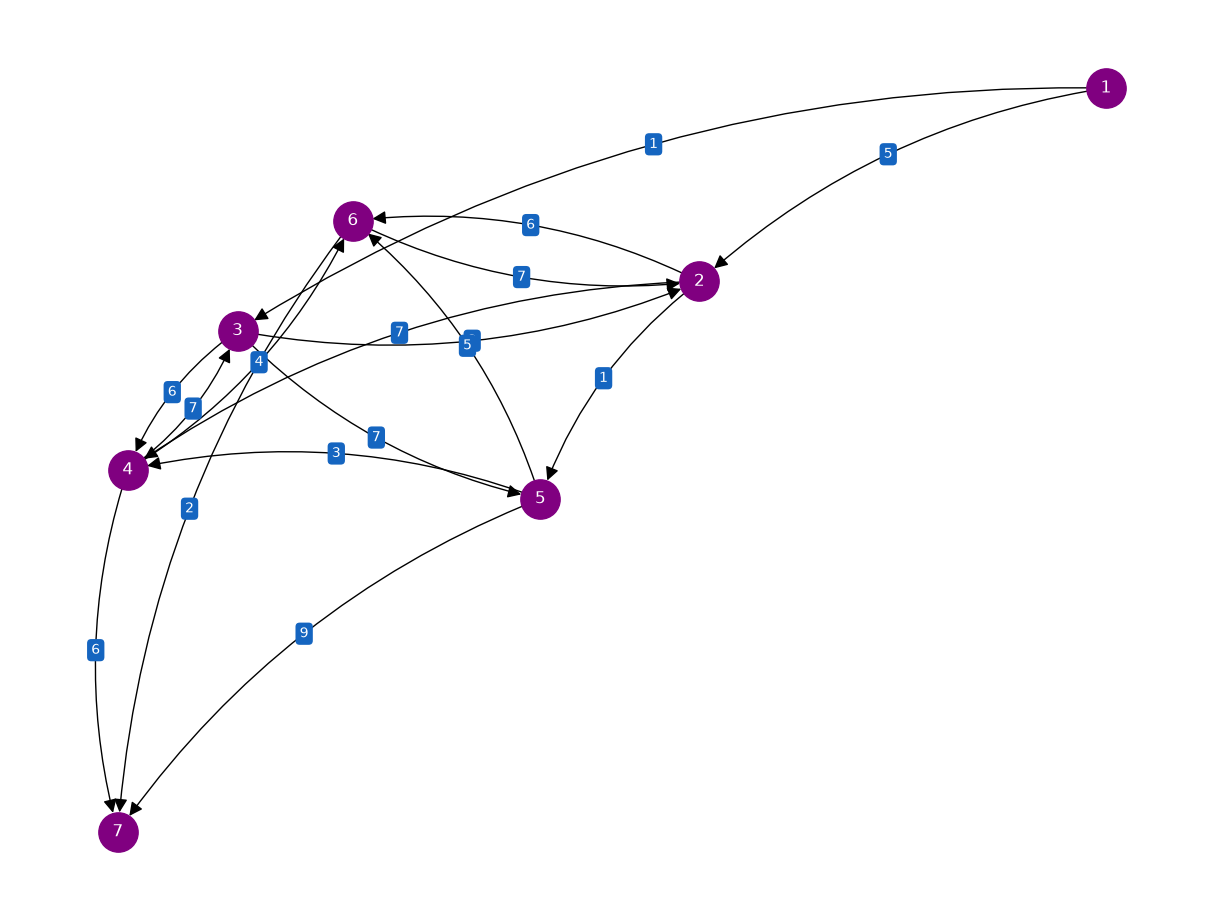

In [8]:
pos_rutas = nx.spring_layout(G_rutas, seed=95)

plt.figure(figsize=(12, 9))

nx.draw(
    G_rutas,
    pos_rutas,
    with_labels=True,
    node_color="purple",
    font_color="white",
    node_size=800,
    arrows=True,
    arrowsize=20,
    connectionstyle="arc3,rad=0.15"
)

pesos = nx.get_edge_attributes(G_rutas, "weight")

nx.draw_networkx_edge_labels(
    G_rutas,
    pos_rutas,
    edge_labels=pesos,
    font_color="white",
    bbox={
        "facecolor": "#1565C0",
        "edgecolor": "none",
        "boxstyle": "round,pad=0.3"
    },
    node_size=800,
    connectionstyle="arc3,rad=0.15",
    rotate=False
)

plt.show()

### <font color="#7B1FA2"><b>2.4. Cálculo de la ruta más corta</b></font>

Ahora calculamos la ruta desde el nodo **1** hasta el nodo **7**
con el <font color="#2E7D32"><b>menor costo total</b></font>.

#### <font color="#00838F"><b>Obtención de la ruta</b></font>

Utilizamos <font color="#1565C0"><b>nx.shortest_path()</b></font>
para obtener una lista con los nodos de una ruta mínima,
en el orden en que debemos recorrerlos.

Indicamos los siguientes argumentos:

| <font color="#1565C0"><b>Argumento</b></font> | <font color="#1565C0"><b>Significado</b></font> |
|:---|:---|
| `G_rutas` | Red dirigida que vamos a resolver. |
| `source=1` | Nodo de origen. |
| `target=7` | Nodo de destino. |
| `weight="weight"` | Atributo que contiene los costos de los arcos. |

Guardamos el resultado en la variable **ruta**.

#### <font color="#00838F"><b>Obtención del costo</b></font>

La función
<font color="#1565C0"><b>nx.shortest_path_length()</b></font>
devuelve el costo mínimo entre el origen y el destino.
Lo guardamos en la variable **costo**.

Al indicar los pesos, ambas funciones utilizan por defecto
el <font color="#1565C0"><b>algoritmo de Dijkstra</b></font>.
Dijkstra es aplicable con costos no negativos; en nuestra red todos son positivos.

> <font color="#C62828"><b>Importante:</b></font>
> **weight="weight"** permite minimizar <u>la suma de los costos</u>.
> Si omitimos este argumento, se minimiza el número de arcos.

In [9]:
ruta = nx.shortest_path(G_rutas, source=1, target=7, weight="weight")
costo = nx.shortest_path_length(G_rutas, source=1, target=7, weight="weight")

print("Ruta más corta:", ruta)
print("Costo total:", costo)

Ruta más corta: [1, 3, 2, 6, 7]
Costo total: 11


### <font color="#7B1FA2"><b>2.5. Obtención de todas las rutas óptimas</b></font>

Puede existir <font color="#2E7D32"><b>más de una ruta</b></font>
con el mismo costo mínimo.

La función **nx.shortest_path()** devuelve una de ellas.
Para obtener todas las rutas óptimas simples —sin repetir nodos— utilizamos
<font color="#1565C0"><b>nx.all_shortest_paths()</b></font>.

Indicamos **source=1**, **target=7** y **weight="weight"**
para utilizar los costos de nuestra red.

Esta función devuelve un **generador**, que permite recorrer
las rutas una por una. Utilizamos **list()** para reunirlas
en una lista y guardarlas en **rutas**.

Después, la instrucción **for** recorre esa lista
y **print()** muestra cada ruta.

> <font color="#2E7D32"><b>Interpretación:</b></font>
> todas las rutas obtenidas alcanzan <u>el mismo costo mínimo</u>. Como los costos son positivos, incorporar un ciclo aumentaría el costo; por ello, las rutas óptimas de este ejercicio son simples.

In [10]:
rutas = list(
    nx.all_shortest_paths(G_rutas, source=1, target=7, weight="weight")
)

print("Todas las rutas óptimas:")

for camino in rutas:
    print(camino)

print("Costo mínimo:", costo)

Todas las rutas óptimas:
[1, 3, 2, 6, 7]
[1, 3, 2, 5, 6, 7]
Costo mínimo: 11


### <font color="#7B1FA2"><b>2.6. Representación de las rutas óptimas sobre la red</b></font>

#### <font color="#00838F"><b>Identificación de los arcos de cada ruta</b></font>

Cada ruta está representada por una lista ordenada de nodos.
Para dibujarla, necesitamos identificar sus
<font color="#1565C0"><b>arcos consecutivos</b></font>.

La expresión **camino[1:]** contiene la lista a partir del segundo nodo.
Al combinarla con **camino** mediante **zip()**, obtenemos:

$$
[v_0,v_1,\ldots,v_k]
\quad\longrightarrow\quad
(v_0,v_1),\;(v_1,v_2),\ldots,(v_{k-1},v_k).
$$

Por ejemplo, para la ruta `[1, 3, 2, 6, 7]`,
los arcos son:

$$
(1,3),\;(3,2),\;(2,6),\;(6,7).
$$

Utilizamos **list()** para reunir estos pares
y guardarlos en la variable **arcos**.

#### <font color="#00838F"><b>Representación sobre la red completa</b></font>

Primero dibujamos la red dirigida **G_rutas** con sus arcos en
<font color="#757575"><b>gris</b></font>.

Después utilizamos
<font color="#1565C0"><b>nx.draw_networkx_edges()</b></font>
con **edgelist=arcos** para resaltar únicamente
las conexiones de la ruta en
<font color="#E65100"><b>naranja</b></font>.

Conservamos las posiciones **pos_rutas** y utilizamos la misma curvatura
para los arcos y sus etiquetas. Así, cada costo queda asociado
a la conexión correspondiente.

Las <u>flechas naranjas</u> indican el sentido de recorrido
desde el origen hasta el destino.

#### <font color="#00838F"><b>Una figura por solución</b></font>

La instrucción **enumerate(rutas, start=1)** proporciona
cada camino junto con su número.

El bloque de dibujo se ejecuta una vez por cada ruta.
La instrucción **plt.figure()**, dentro del ciclo,
crea una figura independiente para cada solución.

En el título, la expresión **f"..."** permite insertar
los valores de **numero** y **costo** entre llaves.

| <font color="#1565C0"><b>Elemento visual</b></font> | <font color="#1565C0"><b>Interpretación</b></font> |
|:---|:---|
| <font color="purple"><b>Nodos morados</b></font> | Nodos de la red. |
| <font color="#757575"><b>Arcos grises</b></font> | Conexiones disponibles que no pertenecen a la ruta mostrada. |
| <font color="darkorange"><b>Arcos naranjas</b></font> | Recorrido de la ruta óptima mostrada. |
| Flechas | Sentido permitido de cada conexión. |
| <font color="#1565C0"><b>Etiquetas azules con texto blanco</b></font> | Costos de los arcos. |

> <font color="#2E7D32"><b>Lectura de las soluciones:</b></font>
> seguimos las flechas naranjas desde el nodo <b>1</b>
> hasta el nodo <b>7</b>. La suma de los costos de cada ruta
> es <u><b>11 unidades</b></u>.

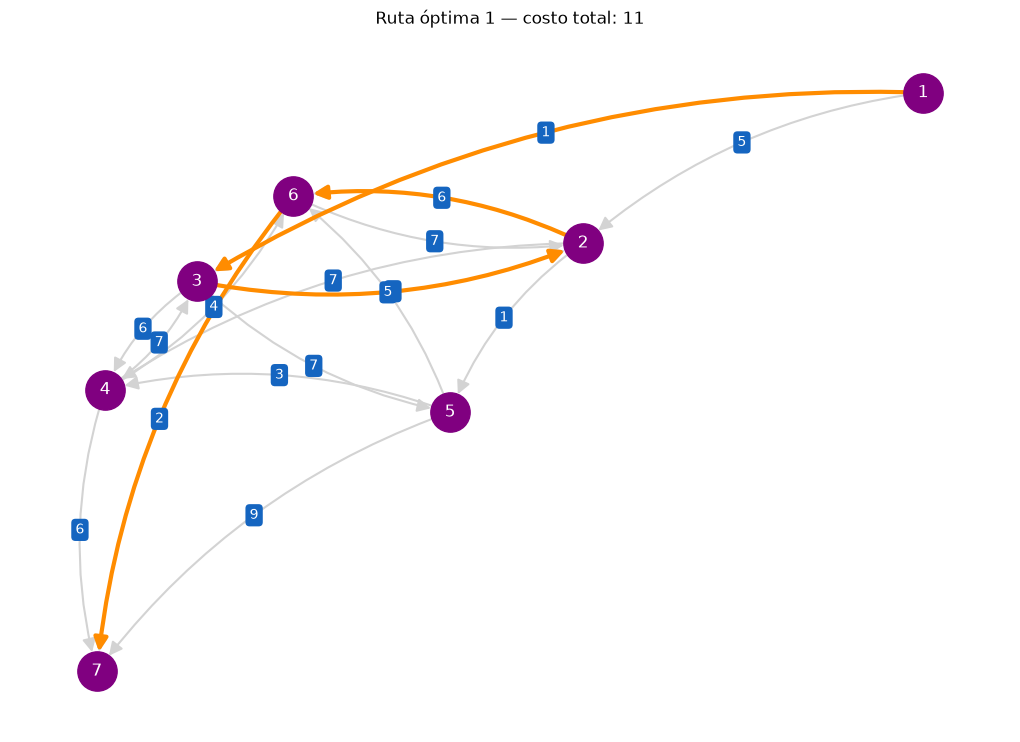

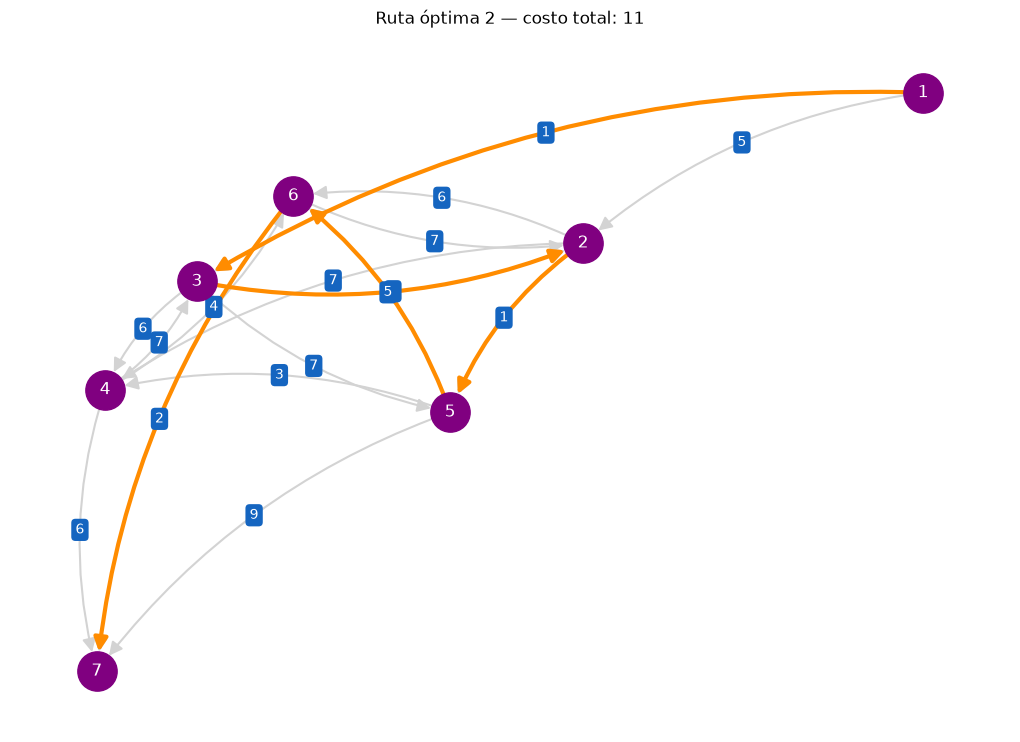

In [11]:
for numero, camino in enumerate(rutas, start=1):

    arcos = list(zip(camino, camino[1:]))

    plt.figure(figsize=(10, 7))

    # Dibujamos la red completa.
    nx.draw(
        G_rutas,
        pos_rutas,
        with_labels=True,
        node_color="purple",
        font_color="white",
        node_size=800,
        edge_color="lightgray",
        width=1.5,
        arrows=True,
        arrowsize=20,
        connectionstyle="arc3,rad=0.15"
    )

    # Resaltamos los arcos de la ruta óptima.
    nx.draw_networkx_edges(
        G_rutas,
        pos_rutas,
        edgelist=arcos,
        edge_color="darkorange",
        width=3,
        node_size=800,
        arrows=True,
        arrowsize=20,
        connectionstyle="arc3,rad=0.15"
    )

    # Mostramos los costos de toda la red.
    pesos = nx.get_edge_attributes(G_rutas, "weight")

    nx.draw_networkx_edge_labels(
        G_rutas,
        pos_rutas,
        edge_labels=pesos,
        font_color="white",
        bbox={
            "facecolor": "#1565C0",
            "edgecolor": "none",
            "boxstyle": "round,pad=0.3"
        },
        node_size=800,
        connectionstyle="arc3,rad=0.15",
        rotate=False
    )

    plt.title(f"Ruta óptima {numero} — costo total: {costo}")
    plt.show()

### <font color="#7B1FA2"><b>2.7. Comprobación del costo de las rutas</b></font>

Ahora sumamos los costos de los arcos de cada ruta
para comprobar los resultados obtenidos.

Recorremos los nodos consecutivos mediante **zip()**.
Para cada arco **u → v**, consultamos su costo con:

**G_rutas[u][v]["weight"]**

Esta expresión accede al atributo **weight** del arco
que conecta el nodo **u** con el nodo **v**.

Primero asignamos **total = 0**. Después agregamos
el costo de cada arco hasta completar la ruta.

La expresión **total == costo** compara ambos valores:
devuelve **True** cuando coinciden y **False** cuando son distintos.

> <font color="#00838F"><b>Propósito de la comprobación:</b></font>
> verificar que la suma de los costos de cada ruta coincide
> con el <u>costo mínimo calculado anteriormente</u>.

In [12]:
for camino in rutas:

    total = 0

    for u, v in zip(camino, camino[1:]):
        total = total + G_rutas[u][v]["weight"]

    print("Ruta:", camino)
    print("Suma de sus costos:", total)
    print("Coincide con el costo mínimo:", total == costo)
    print()

Ruta: [1, 3, 2, 6, 7]
Suma de sus costos: 11
Coincide con el costo mínimo: True

Ruta: [1, 3, 2, 5, 6, 7]
Suma de sus costos: 11
Coincide con el costo mínimo: True



### <font color="#7B1FA2"><b>2.8. Resultado final</b></font>

Las dos rutas obtenidas respetan el sentido de los arcos
y alcanzan el mismo costo mínimo:

| <font color="#1565C0"><b>Ruta</b></font> | <font color="#1565C0"><b>Suma de costos</b></font> | <font color="#1565C0"><b>Costo total</b></font> |
|:---|:---:|:---:|
| $1\rightarrow3\rightarrow2\rightarrow6\rightarrow7$ | $1+2+6+2$ | **11** |
| $1\rightarrow3\rightarrow2\rightarrow5\rightarrow6\rightarrow7$ | $1+2+1+5+2$ | **11** |

La primera ruta contiene **4 arcos** y la segunda **5 arcos**.
Sin embargo, ambas tienen el mismo costo.

Esto muestra que <u>el número de arcos no determina por sí solo
el costo de una ruta</u>.

La suma realizada comprueba el costo de las soluciones.
Su optimalidad se obtiene mediante el algoritmo de Dijkstra,
aplicable porque los pesos de esta red son positivos.

> <font color="#2E7D32"><b>Solución final:</b></font>
> el costo mínimo para ir del nodo <b>1</b> al nodo <b>7</b>
> es <u><b>11 unidades</b></u>, y existen dos rutas que lo alcanzan.

### <font color="#7B1FA2"><b>2.9. Documentación de los comandos</b></font>

| <font color="#1565C0"><b>Comando o expresión</b></font> | <font color="#1565C0"><b>Función</b></font> |
|:---|:---|
| `nx.DiGraph()` | Crear una red dirigida. |
| `G_rutas.add_weighted_edges_from()` | Agregar arcos con sus costos. |
| `nx.spring_layout()` | Calcular posiciones para el dibujo. |
| `nx.draw()` | Dibujar nodos y conexiones. |
| `nx.get_edge_attributes()` | Obtener un atributo de las aristas o arcos. |
| `nx.draw_networkx_edge_labels()` | Mostrar etiquetas sobre las conexiones. |
| `nx.shortest_path()` | Obtener una ruta de costo mínimo al indicar `weight="weight"`. |
| `nx.shortest_path_length()` | Obtener el costo mínimo al indicar `weight="weight"`. |
| `nx.all_shortest_paths()` | Obtener todas las rutas óptimas. |
| `list()` | Reunir las rutas generadas en una lista. |
| `zip(camino, camino[1:])` | Formar pares de nodos consecutivos. |
| `nx.draw_networkx_edges(..., edgelist=arcos)` | Resaltar los arcos de cada ruta sobre la red completa. |
| `enumerate(rutas, start=1)` | Recorrer y numerar las rutas. |
| `G_rutas[u][v]["weight"]` | Consultar el costo de un arco. |
| `plt.figure()` / `plt.title()` / `plt.show()` | Crear, titular y mostrar cada figura. |

#### <font color="#00838F"><b>Documentación oficial</b></font>

- [Obtención de una ruta mínima](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.generic.shortest_path.html)
- [Obtención de la longitud mínima](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.generic.shortest_path_length.html)
- [Obtención de todas las rutas mínimas](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.generic.all_shortest_paths.html)
- [Funciones de representación gráfica](https://networkx.org/documentation/stable/reference/drawing.html)

## <font color="#1565C0"><b>3. Flujo máximo (inciso c)</b></font>

En este inciso utilizamos la red de **actividad_1_b.png** para resolver el problema de <font color="#00838F"><b>flujo máximo</b></font> con NetworkX.

### <font color="#7B1FA2"><b>3.1. Planteamiento del problema</b></font>

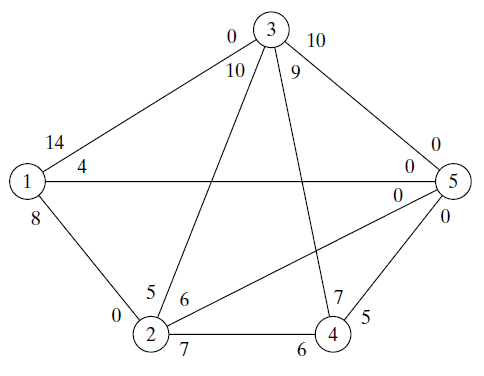

*<font color="#00838F"><b>Figura 2.</b> actividad_1_b.png: Red original con capacidades en ambos sentidos. Fuente: imagen del enunciado de la actividad, proporcionada como material del ejercicio.</font>*

En la imagen, el número junto a un extremo indica la capacidad de salida desde ese nodo hacia el otro. Por ejemplo, entre 2 y 3 leemos $c_{23}=5$ y $c_{32}=10$. Los sentidos con capacidad cero se omiten al construir la red.

Buscamos <u>la mayor cantidad de flujo que puede enviarse del nodo 1 al nodo 5</u>, respetando las capacidades de los arcos.

| <font color="#1565C0"><b>Elemento</b></font> | <font color="#1565C0"><b>Descripción</b></font> |
|---|---|
| **Fuente: nodo 1** | Punto de entrada del flujo a la red. |
| **Sumidero: nodo 5** | Destino del flujo. |
| **Nodos intermedios: 2, 3 y 4** | El flujo que entra debe ser igual al que sale. |
| **Algoritmo: Edmonds–Karp** | Método de caminos aumentantes que utiliza búsqueda en anchura. |

#### <font color="#00838F"><b>Formulación</b></font>

Denotamos por $c_{ij}$ la **capacidad** del arco $i\to j$ y por $f_{ij}$ su **flujo**. El problema consiste en:

$$
\max F=f_{12}+f_{13}+f_{15},
$$

sujeto a las restricciones de capacidad:

$$
0\leq f_{ij}\leq c_{ij},
\qquad (i,j)\in A,
$$

y de conservación del flujo:

$$
\sum_{i:\,(i,j)\in A}f_{ij}
=
\sum_{k:\,(j,k)\in A}f_{jk},
\qquad j\in\{2,3,4\}.
$$

Aquí, $A$ es el **conjunto de arcos** de la red dirigida $G=(V,A)$. Trabajamos con **flujos reales no negativos**. En esta red no hay arcos que entren a la fuente ni que salgan del sumidero.

#### <font color="#00838F"><b>Resultados que buscamos</b></font>

| <font color="#1565C0"><b>Resultado</b></font> | <font color="#1565C0"><b>Interpretación</b></font> |
|---|---|
| **Valor máximo $F^*$** | Mayor cantidad de flujo que puede enviarse de la fuente al sumidero. |
| **Distribución óptima $(f_{ij})$** | Flujo asignado a cada arco para alcanzar $F^*$. |

> <font color="#C62828"><b>El valor máximo es único, pero la distribución óptima puede no serlo.</b></font>

`nx.maximum_flow()` devuelve **una distribución óptima por ejecución**. En esta red existen infinitas distribuciones óptimas si admitimos flujos reales; describimos su conjunto mediante **parámetros y restricciones**, y dibujamos ejemplos para mostrar la falta de unicidad.

### <font color="#7B1FA2"><b>3.2. Construcción de la red dirigida</b></font>

Creamos la red con **`nx.DiGraph()`**, porque las capacidades dependen de la dirección de cada arco.

Por ejemplo, entre los nodos 2 y 3 tenemos:

| <font color="#1565C0"><b>Arco</b></font> | <font color="#1565C0"><b>Capacidad</b></font> |
|:---:|:---:|
| $2\to3$ | $c_{23}=5$ |
| $3\to2$ | $c_{32}=10$ |

Estos son <u>dos arcos distintos</u>, aunque conecten los mismos nodos.

#### <font color="#00838F"><b>Registro de las capacidades</b></font>

Agregamos los arcos con `G_flujo.add_weighted_edges_from()`, mediante tuplas de la forma **`(origen, destino, capacidad)`**.

El argumento **`weight="capacity"`** guarda cada capacidad en el atributo llamado <font color="#00838F"><b>capacity</b></font>.

Omitimos los sentidos con capacidad cero de la imagen, pues no permiten transportar flujo.

In [13]:
# Creamos la red dirigida del problema de flujo máximo.
G_flujo = nx.DiGraph()

# Registramos las capacidades de los arcos.
G_flujo.add_weighted_edges_from(
    [
        (1, 2, 8),
        (1, 3, 14),
        (1, 5, 4),

        (2, 3, 5),
        (2, 4, 7),
        (2, 5, 6),

        (3, 2, 10),
        (3, 4, 9),
        (3, 5, 10),

        (4, 2, 6),
        (4, 3, 7),
        (4, 5, 5),
    ],
    weight="capacity"
)

#### <font color="#00838F"><b>Comentarios sobre la sintaxis</b></font>

| <font color="#1565C0"><b>Comando o elemento</b></font> | <font color="#1565C0"><b>Funcionamiento</b></font> |
|---|---|
| `G_flujo = nx.DiGraph()` | Crea un grafo dirigido vacío y lo guarda en `G_flujo`. |
| `[...]` | Define la lista de arcos. |
| `(1, 2, 8)` | Representa el arco $1\to2$ con capacidad 8. |
| `G_flujo.add_weighted_edges_from(...)` | Agrega los arcos y sus valores. |
| `weight="capacity"` | Establece el nombre del atributo que almacenará los valores. |
| `#` | Introduce un comentario que Python no ejecuta. |

Los **nodos se agregan automáticamente** al registrar los arcos.

#### <font color="#00838F"><b>Comprobación de los datos</b></font>

Consultamos el número de nodos y arcos, además de las capacidades en ambos sentidos entre los nodos 2 y 3.

| <font color="#1565C0"><b>Consulta</b></font> | <font color="#1565C0"><b>Resultado que obtiene</b></font> |
|---|---|
| `G_flujo.number_of_nodes()` | Número de nodos. |
| `G_flujo.number_of_edges()` | Número de arcos. |
| `G_flujo[2][3]["capacity"]` | Capacidad del arco $2\to3$. |
| `G_flujo[3][2]["capacity"]` | Capacidad del arco $3\to2$. |

In [14]:
print("Número de nodos:", G_flujo.number_of_nodes())
print("Número de arcos:", G_flujo.number_of_edges())

print("Capacidad de 2 → 3:", G_flujo[2][3]["capacity"])
print("Capacidad de 3 → 2:", G_flujo[3][2]["capacity"])

Número de nodos: 5
Número de arcos: 12
Capacidad de 2 → 3: 5
Capacidad de 3 → 2: 10


### <font color="#7B1FA2"><b>3.3. Representación gráfica de la red</b></font>

Dibujamos la **red completa** antes de resolver el problema. Las flechas indican la dirección de los arcos y sus etiquetas muestran las <font color="#00838F"><b>capacidades</b></font>.

#### <font color="#00838F"><b>Comandos para el dibujo</b></font>

| <font color="#1565C0"><b>Comando o argumento</b></font> | <font color="#1565C0"><b>Funcionamiento</b></font> |
|---|---|
| `nx.spring_layout(G_flujo, seed=3000)` | Calcula las posiciones de los nodos. La semilla permite reproducir la disposición. |
| `nx.draw(G_flujo, pos_flujo, ...)` | Dibuja los nodos y arcos en esas posiciones. |
| `with_labels=True` | Muestra los números de los nodos. |
| `arrows=True` | Muestra la dirección de los arcos. |
| `connectionstyle="arc3,rad=0.15"` | Curva los arcos para separar los sentidos opuestos. |
| `nx.get_edge_attributes(G_flujo, "capacity")` | Obtiene un diccionario con las capacidades. |
| `nx.draw_networkx_edge_labels(...)` | Coloca las capacidades sobre los arcos. |
| `font_color="white"` | Muestra el texto de las capacidades en blanco. |
| `bbox={...}` | Coloca cada etiqueta sobre un recuadro azul, con el formato de **1.3**. |

> <font color="#C62828"><b>Usamos la misma curvatura y el mismo tamaño de nodo al dibujar los arcos y sus etiquetas.</b></font>

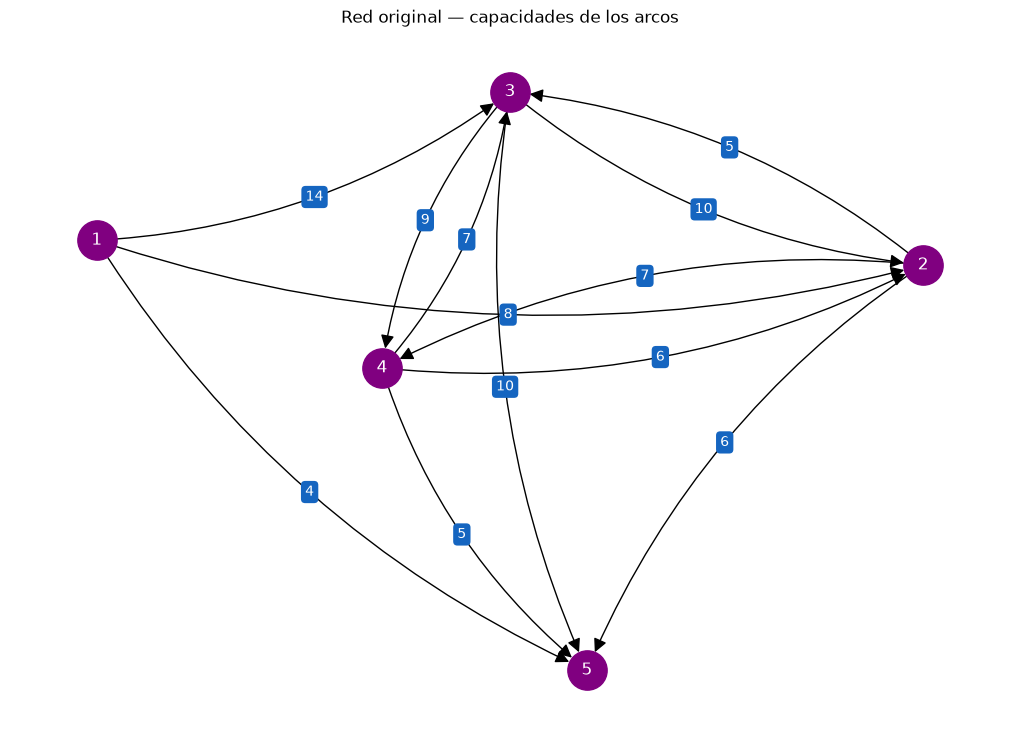

In [15]:
# Calculamos las posiciones de los nodos.
pos_flujo = nx.spring_layout(G_flujo, seed=3000)

plt.figure(figsize=(10, 7))

# Dibujamos la red dirigida.
nx.draw(
    G_flujo,
    pos_flujo,
    with_labels=True,
    node_color="purple",
    font_color="white",
    node_size=800,
    arrows=True,
    arrowsize=20,
    connectionstyle="arc3,rad=0.15"
)

# Obtenemos y mostramos las capacidades.
capacidades = nx.get_edge_attributes(G_flujo, "capacity")

nx.draw_networkx_edge_labels(
    G_flujo,
    pos_flujo,
    edge_labels=capacidades,
    font_color="white",
    bbox={
        "facecolor": "#1565C0",
        "edgecolor": "none",
        "boxstyle": "round,pad=0.3"
    },
    node_size=800,
    connectionstyle="arc3,rad=0.15",
    rotate=False
)

plt.title("Red original — capacidades de los arcos")
plt.show()

### <font color="#7B1FA2"><b>3.4. Resolución mediante NetworkX</b></font>

Importamos **Edmonds–Karp** desde el módulo `networkx.algorithms.flow` y lo seleccionamos mediante el argumento **`flow_func`** de `nx.maximum_flow()`.

#### <font color="#00838F"><b>Fundamento de Edmonds–Karp</b></font>

Edmonds–Karp aplica el método de **caminos aumentantes** de Ford–Fulkerson. Partimos de un flujo nulo y repetimos:

1. Buscamos en la **red residual**, mediante búsqueda en anchura (**BFS**), un camino de la fuente al sumidero con el menor número de arcos.
2. Aumentamos el flujo en la cantidad permitida por su **cuello de botella**:

   $$\Delta=\min_{(i,j)\in P}r_{ij},$$

   donde $r_{ij}$ es la capacidad residual y $P$ el camino aumentante.
3. Actualizamos la red residual y continuamos hasta que no exista otro camino aumentante.

Los arcos residuales inversos permiten **deshacer flujo previamente asignado** para aprovechar otras rutas. NetworkX realiza estas operaciones al ejecutar el algoritmo.

#### <font color="#00838F"><b>Argumentos de la función</b></font>

| <font color="#1565C0"><b>Argumento</b></font> | <font color="#1565C0"><b>Significado</b></font> |
|---|---|
| `G_flujo` | Red dirigida con las capacidades registradas. |
| `1` | Nodo fuente. |
| `5` | Nodo sumidero. |
| `capacity="capacity"` | Indica dónde están almacenadas las capacidades. |
| `flow_func=edmonds_karp` | Selecciona el algoritmo de caminos aumentantes. |

Escribimos **`edmonds_karp` sin paréntesis**, porque pasamos la función como argumento para que NetworkX la ejecute.

#### <font color="#00838F"><b>Resultados que devuelve</b></font>

| <font color="#1565C0"><b>Variable</b></font> | <font color="#1565C0"><b>Contenido</b></font> |
|---|---|
| `flujo_maximo` | Valor máximo del flujo. |
| `flujo` | Diccionario con el flujo asignado a cada arco. |

La asignación **`flujo_maximo, flujo = ...`** guarda los dos resultados, en ese orden.

In [16]:
from networkx.algorithms.flow import edmonds_karp

# Calculamos el valor máximo y una distribución óptima.
flujo_maximo, flujo = nx.maximum_flow(
    G_flujo,
    1,
    5,
    capacity="capacity",
    flow_func=edmonds_karp
)

print("Flujo máximo:", flujo_maximo)

Flujo máximo: 25


#### <font color="#00838F"><b>Valor obtenido y consulta de los flujos</b></font>

El algoritmo obtiene:

$$
\boxed{F^*=25}
$$

<font color="#2E7D32"><b>La red permite transportar un máximo de 25 unidades de flujo del nodo 1 al nodo 5.</b></font>

Para conocer cómo se distribuye ese flujo, consultamos el diccionario **`flujo`**:

| <font color="#1565C0"><b>Expresión</b></font> | <font color="#1565C0"><b>Información</b></font> |
|---|---|
| `flujo[u][v]` | Flujo asignado al arco $u\to v$. |
| `G_flujo[u][v]["capacity"]` | Capacidad del mismo arco. |
| `G_flujo.edges()` | Arcos de la red que recorreremos. |

El ciclo **`for u, v in G_flujo.edges()`** toma los extremos de cada arco. La cadena **`f"..."`** incorpora los valores escritos entre llaves.

Mostramos cada arco en el formato <u>flujo / capacidad</u>: a la izquierda estará el flujo utilizado y a la derecha su capacidad.

In [17]:
for u, v in G_flujo.edges():
    cantidad = flujo[u][v]
    capacidad = G_flujo[u][v]["capacity"]

    print(f"{u} → {v}: {cantidad} / {capacidad}")

1 → 2: 8 / 8
1 → 3: 13 / 14
1 → 5: 4 / 4
2 → 3: 0 / 5
2 → 4: 2 / 7
2 → 5: 6 / 6
3 → 2: 0 / 10
3 → 4: 3 / 9
3 → 5: 10 / 10
4 → 2: 0 / 6
4 → 3: 0 / 7
4 → 5: 5 / 5


#### <font color="#00838F"><b>Distribución óptima obtenida</b></font>

Con el orden de arcos registrado, obtenemos esta distribución:

| <font color="#1565C0"><b>Arco</b></font> | <font color="#2E7D32"><b>Flujo</b></font> | <font color="#1565C0"><b>Capacidad</b></font> |
|:---:|:---:|:---:|
| $1\to2$ | **8** | 8 |
| $1\to3$ | **13** | 14 |
| $1\to5$ | **4** | 4 |
| $2\to3$ | 0 | 5 |
| $2\to4$ | **2** | 7 |
| $2\to5$ | **6** | 6 |
| $3\to2$ | 0 | 10 |
| $3\to4$ | **3** | 9 |
| $3\to5$ | **10** | 10 |
| $4\to2$ | 0 | 6 |
| $4\to3$ | 0 | 7 |
| $4\to5$ | **5** | 5 |

El flujo que sale de la fuente es:

$$
F=f_{12}+f_{13}+f_{15}=8+13+4=25.
$$

Y el que llega al sumidero es:

$$
F=f_{15}+f_{25}+f_{35}+f_{45}
=4+6+10+5=25.
$$

> <font color="#00838F"><b>Esta es una distribución óptima. En 3.7 describimos el conjunto completo de soluciones.</b></font>

En el siguiente apartado resaltamos esta distribución sobre la red completa.

### <font color="#7B1FA2"><b>3.5. Representación de la solución sobre la red</b></font>

Dibujamos la **red completa** y resaltamos los arcos que transportan flujo, conservando las posiciones guardadas en **`pos_flujo`**.

| <font color="#1565C0"><b>Elemento gráfico</b></font> | <font color="#1565C0"><b>Significado</b></font> |
|---|---|
| <font color="purple"><b>Nodos morados</b></font> | Nodos de la red original. |
| <font color="gray"><b>Arcos grises</b></font> | Arcos con flujo cero en esta distribución. |
| <font color="darkorange"><b>Arcos naranjas</b></font> | Arcos que transportan flujo positivo. |
| **Etiqueta $f_{ij}\,/\,c_{ij}$** | Flujo utilizado y capacidad del arco, con texto blanco sobre fondo azul. |

Por ejemplo, **13 / 14** indica que circulan 13 unidades por un arco cuya capacidad es 14.

#### <font color="#00838F"><b>Selección de los arcos y sus etiquetas</b></font>

| <font color="#1565C0"><b>Elemento del código</b></font> | <font color="#1565C0"><b>Funcionamiento</b></font> |
|---|---|
| `arcos_con_flujo` | Lista de arcos que cumplen `flujo[u][v] > 0`. |
| `etiquetas` | Diccionario que asocia cada arco con su texto **flujo / capacidad**. |
| `edgelist=arcos_con_flujo` | Selecciona los arcos que se dibujarán en naranja. |
| `width=3` | Aumenta el grosor de los arcos resaltados. |

Las expresiones con **`for` dentro de `[...]` y `{...}`** construyen una lista y un diccionario, respectivamente, recorriendo los arcos de la red.

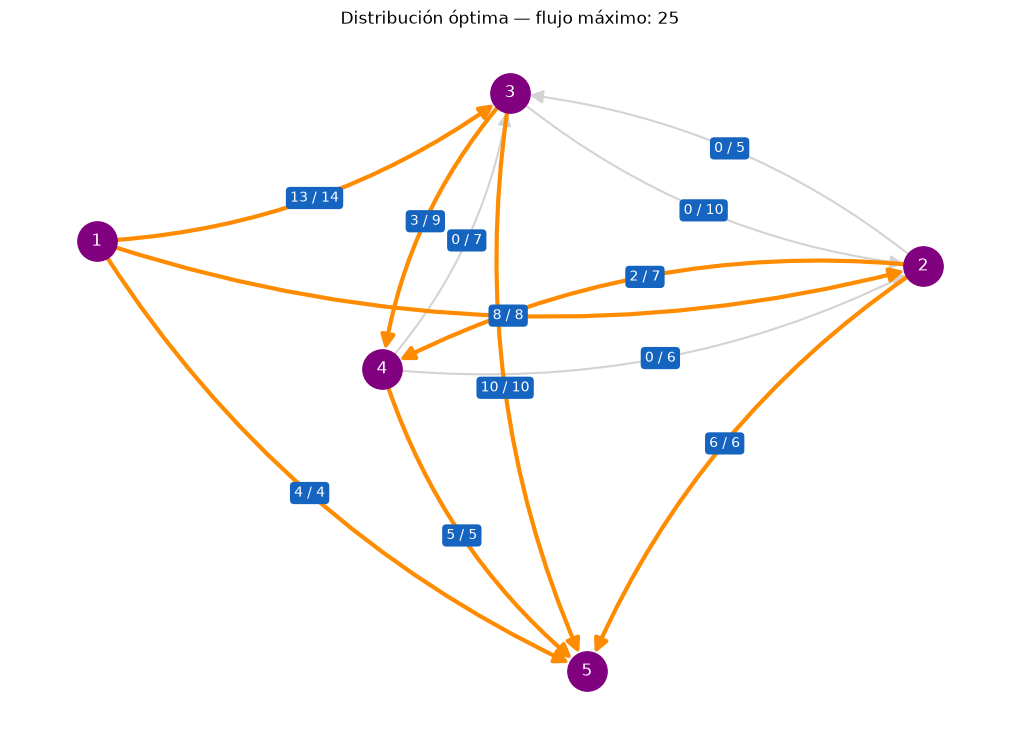

In [18]:
# Seleccionamos los arcos con flujo positivo.
arcos_con_flujo = [
    (u, v) for u, v in G_flujo.edges()
    if flujo[u][v] > 0
]

# Creamos las etiquetas: flujo / capacidad.
etiquetas = {
    (u, v): f"{flujo[u][v]} / {G_flujo[u][v]['capacity']}"
    for u, v in G_flujo.edges()
}

plt.figure(figsize=(10, 7))

# Dibujamos la red completa.
nx.draw(
    G_flujo,
    pos_flujo,
    with_labels=True,
    node_color="purple",
    font_color="white",
    node_size=800,
    edge_color="lightgray",
    width=1.5,
    arrows=True,
    arrowsize=20,
    connectionstyle="arc3,rad=0.15"
)

# Resaltamos los arcos que transportan flujo.
nx.draw_networkx_edges(
    G_flujo,
    pos_flujo,
    edgelist=arcos_con_flujo,
    edge_color="darkorange",
    width=3,
    node_size=800,
    arrows=True,
    arrowsize=20,
    connectionstyle="arc3,rad=0.15"
)

# Mostramos las etiquetas de todos los arcos.
nx.draw_networkx_edge_labels(
    G_flujo,
    pos_flujo,
    edge_labels=etiquetas,
    font_color="white",
    bbox={
        "facecolor": "#1565C0",
        "edgecolor": "none",
        "boxstyle": "round,pad=0.3"
    },
    node_size=800,
    connectionstyle="arc3,rad=0.15",
    rotate=False
)

plt.title(f"Distribución óptima — flujo máximo: {flujo_maximo}")
plt.show()

### <font color="#7B1FA2"><b>3.6. Comprobación de la solución</b></font>

Comprobamos dos aspectos: que la distribución sea **factible** y que alcance el **valor máximo**.

#### <font color="#00838F"><b>Capacidades y conservación del flujo</b></font>

| <font color="#1565C0"><b>Condición</b></font> | <font color="#1565C0"><b>Comprobación</b></font> |
|---|---|
| **Capacidad** | En cada arco debe cumplirse $0\leq f_{ij}\leq c_{ij}$. |
| **Conservación** | En los nodos 2, 3 y 4, el flujo entrante debe igualar al saliente. |

En el código utilizamos:

| <font color="#1565C0"><b>Comando</b></font> | <font color="#1565C0"><b>Funcionamiento</b></font> |
|---|---|
| `all(...)` | Devuelve `True` si todas las condiciones evaluadas se cumplen. |
| `G_flujo.predecessors(nodo)` | Obtiene los nodos con un arco dirigido hacia `nodo`. |
| `G_flujo.successors(nodo)` | Obtiene los nodos hacia los que sale un arco desde `nodo`. |
| `sum(...)` | Suma los flujos correspondientes. |
| `entrada == salida` | Compara ambos valores y devuelve `True` o `False`. |

In [19]:
# Comprobamos las capacidades de todos los arcos.
respeta_capacidades = all(
    0 <= flujo[u][v] <= G_flujo[u][v]["capacity"]
    for u, v in G_flujo.edges()
)

print("Respeta las capacidades:", respeta_capacidades)

# Comprobamos la conservación en los nodos intermedios.
for nodo in (2, 3, 4):
    entrada = sum(
        flujo[u][nodo] for u in G_flujo.predecessors(nodo)
    )

    salida = sum(
        flujo[nodo][v] for v in G_flujo.successors(nodo)
    )

    print(
        f"Nodo {nodo}: entrada={entrada}, salida={salida}, "
        f"conserva={entrada == salida}"
    )

Respeta las capacidades: True
Nodo 2: entrada=8, salida=8, conserva=True
Nodo 3: entrada=13, salida=13, conserva=True
Nodo 4: entrada=5, salida=5, conserva=True


Los resultados son:

| <font color="#1565C0"><b>Nodo</b></font> | <font color="#1565C0"><b>Flujo entrante</b></font> | <font color="#1565C0"><b>Flujo saliente</b></font> | <font color="#2E7D32"><b>Conservación</b></font> |
|:---:|:---:|:---:|:---:|
| 2 | 8 | 8 | **True** |
| 3 | 13 | 13 | **True** |
| 4 | 5 | 5 | **True** |

La comprobación de las capacidades también devuelve **`True`**.

> <font color="#2E7D32"><b>La distribución obtenida es factible.</b></font>

#### <font color="#00838F"><b>Comprobación mediante un corte mínimo</b></font>

El **teorema de flujo máximo y corte mínimo** establece que el valor del flujo máximo coincide con la capacidad de un corte mínimo.

Usamos **`nx.minimum_cut()`** con la misma fuente, sumidero, atributo de capacidad y algoritmo.

| <font color="#1565C0"><b>Resultado</b></font> | <font color="#1565C0"><b>Contenido</b></font> |
|---|---|
| `valor_corte` | Capacidad del corte mínimo. |
| `particion` | Dos conjuntos de nodos: **S**, que contiene la fuente, y **R**, que contiene el sumidero. |

La asignación **`S, R = particion`** separa ambos conjuntos. Utilizamos **`sorted()`** para mostrar sus nodos ordenados.

In [20]:
# Calculamos un corte mínimo.
valor_corte, particion = nx.minimum_cut(
    G_flujo,
    1,
    5,
    capacity="capacity",
    flow_func=edmonds_karp
)

S, R = particion

print("Capacidad del corte mínimo:", valor_corte)
print("Lado de la fuente:", sorted(S))
print("Lado del sumidero:", sorted(R))

print(
    "Flujo máximo = capacidad del corte:",
    flujo_maximo == valor_corte
)

Capacidad del corte mínimo: 25
Lado de la fuente: [1, 2, 3, 4]
Lado del sumidero: [5]
Flujo máximo = capacidad del corte: True


#### <font color="#00838F"><b>Certificado de optimalidad</b></font>

NetworkX obtiene el corte:

$$
S=\{1,2,3,4\},
\qquad
R=\{5\}.
$$

Su capacidad es la suma de las capacidades de los arcos que van de **S** hacia **R**:

| <font color="#1565C0"><b>Arco del corte</b></font> | <font color="#1565C0"><b>Capacidad</b></font> |
|:---:|:---:|
| $1\to5$ | 4 |
| $2\to5$ | 6 |
| $3\to5$ | 10 |
| $4\to5$ | 5 |
| **Total** | <font color="#2E7D32"><b>25</b></font> |

Todo flujo factible está limitado por esta capacidad:

$$
F\leq c(S,R)=4+6+10+5=25.
$$

La distribución que verificamos alcanza exactamente esa cota. Por tanto:

$$
\boxed{F^*=25}
$$

> <font color="#2E7D32"><b>La solución es factible y óptima: transporta 25 unidades de la fuente al sumidero.</b></font>

En **3.7** analizamos la falta de unicidad y caracterizamos el conjunto completo de distribuciones óptimas.

### <font color="#7B1FA2"><b>3.7. Soluciones óptimas alternativas</b></font>

El valor máximo es **25**, pero podemos alcanzarlo con distintas distribuciones de flujo.

#### <font color="#00838F"><b>Caracterización de todas las soluciones</b></font>

Las capacidades de los cuatro arcos que llegan al sumidero suman 25. Por ello, <u>toda solución óptima debe saturarlos</u>:

$$
f_{15}=4,\qquad f_{25}=6,\qquad f_{35}=10,\qquad f_{45}=5.
$$

Además, como $f_{12}+f_{13}+f_{15}=25$, tenemos:

$$
f_{12}+f_{13}=21.
$$

Definimos cinco parámetros:

$$
a=f_{12},\quad b=f_{23},\quad c=f_{24},\quad
d=f_{42},\quad e=f_{43}.
$$

La conservación en los nodos 2 y 4 exige:

$$
\begin{aligned}
a+f_{32}+d&=b+c+6,\\
c+f_{34}&=d+e+5.
\end{aligned}
$$

Despejamos $f_{32}$ y $f_{34}$. Así, **todas las distribuciones óptimas** tienen la siguiente forma:

| <font color="#1565C0"><b>Arco</b></font> | <font color="#00838F"><b>Flujo</b></font> | <font color="#1565C0"><b>Capacidad</b></font> |
|:---:|:---:|:---:|
| $1\to2$ | $a$ | 8 |
| $1\to3$ | $21-a$ | 14 |
| $1\to5$ | **4** | 4 |
| $2\to3$ | $b$ | 5 |
| $2\to4$ | $c$ | 7 |
| $2\to5$ | **6** | 6 |
| $3\to2$ | $6+b+c-d-a$ | 10 |
| $3\to4$ | $5-c+d+e$ | 9 |
| $3\to5$ | **10** | 10 |
| $4\to2$ | $d$ | 6 |
| $4\to3$ | $e$ | 7 |
| $4\to5$ | **5** | 5 |

#### <font color="#00838F"><b>Condiciones de los parámetros</b></font>

La cota $7\leq a\leq8$ resulta de $f_{12}\leq8$ y $f_{13}=21-a\leq14$. Para respetar las capacidades de todos los arcos, elegimos valores reales que cumplan:

$$
\begin{aligned}
&7\leq a\leq8,\\
&0\leq b\leq5,\qquad 0\leq c\leq7,\\
&0\leq d\leq6,\qquad 0\leq e\leq7,\\
&0\leq6+b+c-d-a\leq10,\\
&0\leq5-c+d+e\leq9.
\end{aligned}
$$

La conservación en el nodo 3 también queda satisfecha: tanto el flujo entrante como el saliente se reducen a $21-a+b+e$.

> <font color="#2E7D32"><b>Cada elección admisible genera una solución óptima, y toda solución óptima del modelo aparece en esta caracterización.</b></font>

Esta descripción también incluye **circulaciones**, es decir, flujo que recorre un ciclo sin cambiar el valor enviado al sumidero. Son admisibles si respetan capacidades y conservación. Así, describimos todas las soluciones del modelo, incluidas las que no devuelve una sola ejecución del algoritmo.

#### <font color="#00838F"><b>Construcción de ejemplos en Python</b></font>

Elegimos tres combinaciones de parámetros para comparar sus distribuciones:

| <font color="#1565C0"><b>Distribución</b></font> | <font color="#1565C0"><b>Parámetros $(a,b,c,d,e)$</b></font> |
|:---:|:---:|
| **1** | $(8,0,2,0,0)$ |
| **2** | $(7.5,0,1.5,0,0)$ |
| **3** | $(7,0,1,0,0)$ |

La primera coincide con la obtenida mediante Edmonds–Karp. La segunda utiliza **flujos fraccionarios**.

| <font color="#1565C0"><b>Elemento del código</b></font> | <font color="#1565C0"><b>Funcionamiento</b></font> |
|---|---|
| `for a, b, c, d, e in parametros` | Asigna los cinco valores de cada tupla a sus variables. |
| `alternativa` | Diccionario de flujos construido con las expresiones de la tabla. |
| `soluciones.append(alternativa)` | Agrega la distribución a la lista de ejemplos. |
| `5: {}` | Registra que el sumidero no tiene arcos de salida en esta red. |

> <font color="#C62828"><b>Estos tres ejemplos ilustran el conjunto completo descrito anteriormente; no constituyen una enumeración de todas las soluciones reales.</b></font>

In [21]:
# Elegimos tres combinaciones admisibles de parámetros.
parametros = [
    (8, 0, 2, 0, 0),
    (7.5, 0, 1.5, 0, 0),
    (7, 0, 1, 0, 0)
]

soluciones = []

for a, b, c, d, e in parametros:
    alternativa = {
        1: {2: a, 3: 21 - a, 5: 4},
        2: {3: b, 4: c, 5: 6},
        3: {
            2: 6 + b + c - d - a,
            4: 5 - c + d + e,
            5: 10
        },
        4: {2: d, 3: e, 5: 5},
        5: {}
    }

    soluciones.append(alternativa)

#### <font color="#00838F"><b>Verificación de las distribuciones</b></font>

Aplicamos las mismas comprobaciones del apartado anterior:

| <font color="#1565C0"><b>Comprobación</b></font> | <font color="#1565C0"><b>Condición</b></font> |
|---|---|
| **Capacidades** | Todos los flujos están entre cero y la capacidad de su arco. |
| **Conservación** | El flujo entrante coincide con el saliente en cada nodo intermedio. |
| **Optimalidad** | La distribución es factible y su valor coincide con la capacidad del corte mínimo. |

**`sum(alternativa[1].values())`** suma los flujos que salen de la fuente. El operador **`and`** exige que se cumplan simultáneamente las tres condiciones.

In [22]:
for numero, alternativa in enumerate(soluciones, start=1):
    # Comprobamos las capacidades.
    capacidades_ok = all(
        0 <= alternativa[u][v] <= G_flujo[u][v]["capacity"]
        for u, v in G_flujo.edges()
    )

    # Comprobamos la conservación del flujo.
    conservacion_ok = all(
        sum(alternativa[u][nodo] for u in G_flujo.predecessors(nodo))
        ==
        sum(alternativa[nodo][v] for v in G_flujo.successors(nodo))
        for nodo in (2, 3, 4)
    )

    valor = sum(alternativa[1].values())

    es_optima = (
        capacidades_ok
        and conservacion_ok
        and valor == valor_corte
    )

    print(f"Distribución {numero}:")
    print("Flujo total:", valor)
    print("Respeta las capacidades:", capacidades_ok)
    print("Conserva el flujo:", conservacion_ok)
    print("Es óptima:", es_optima)
    print()

Distribución 1:
Flujo total: 25
Respeta las capacidades: True
Conserva el flujo: True
Es óptima: True

Distribución 2:
Flujo total: 25.0
Respeta las capacidades: True
Conserva el flujo: True
Es óptima: True

Distribución 3:
Flujo total: 25
Respeta las capacidades: True
Conserva el flujo: True
Es óptima: True



#### <font color="#00838F"><b>Representación de las distribuciones alternativas</b></font>

Las tres distribuciones cumplen las comprobaciones y alcanzan **25 unidades de flujo**.

Dibujamos cada una sobre la **red completa**, utilizando las mismas posiciones:

| <font color="#1565C0"><b>Representación</b></font> | <font color="#1565C0"><b>Significado</b></font> |
|---|---|
| <font color="darkorange"><b>Arcos naranjas</b></font> | Flujo positivo en la distribución mostrada. |
| <font color="gray"><b>Arcos grises</b></font> | Flujo cero en esa distribución. |
| **Flujo / capacidad** | Cantidad utilizada y límite del arco. |

El dibujo se realiza dentro del ciclo **`for`**, por lo que se genera una figura para cada ejemplo.

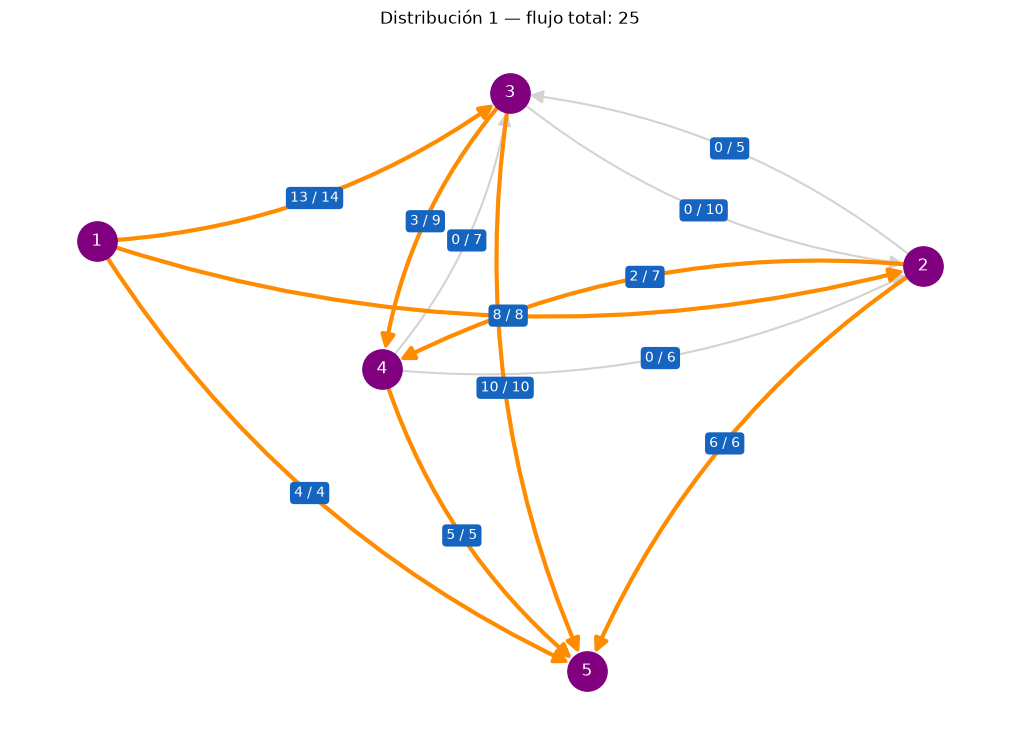

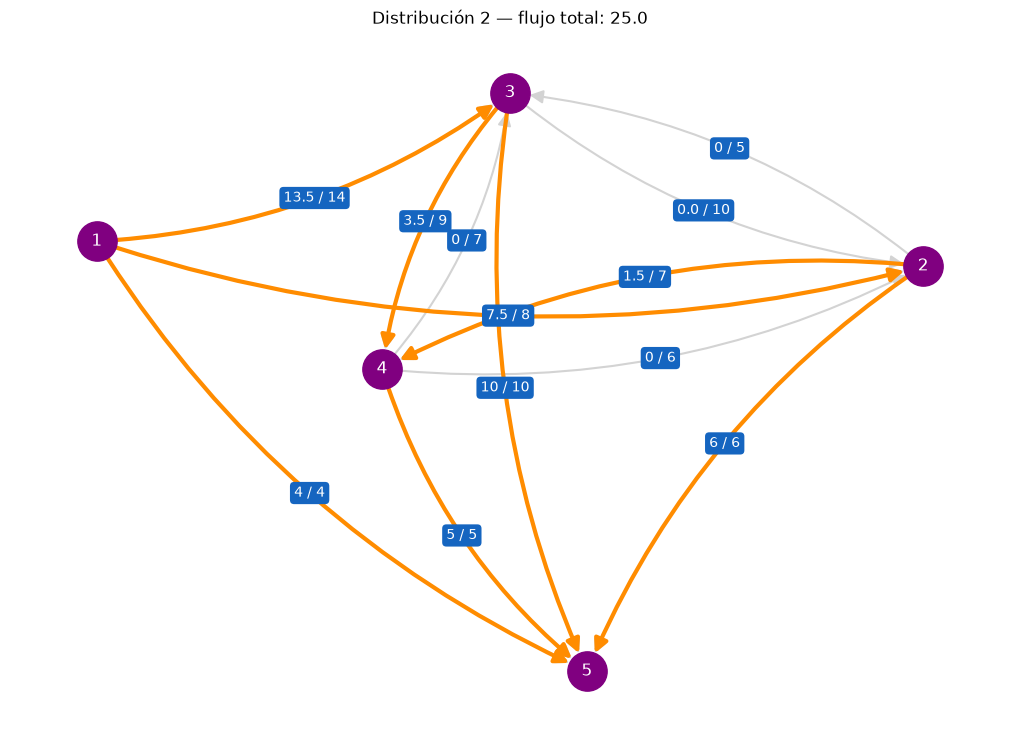

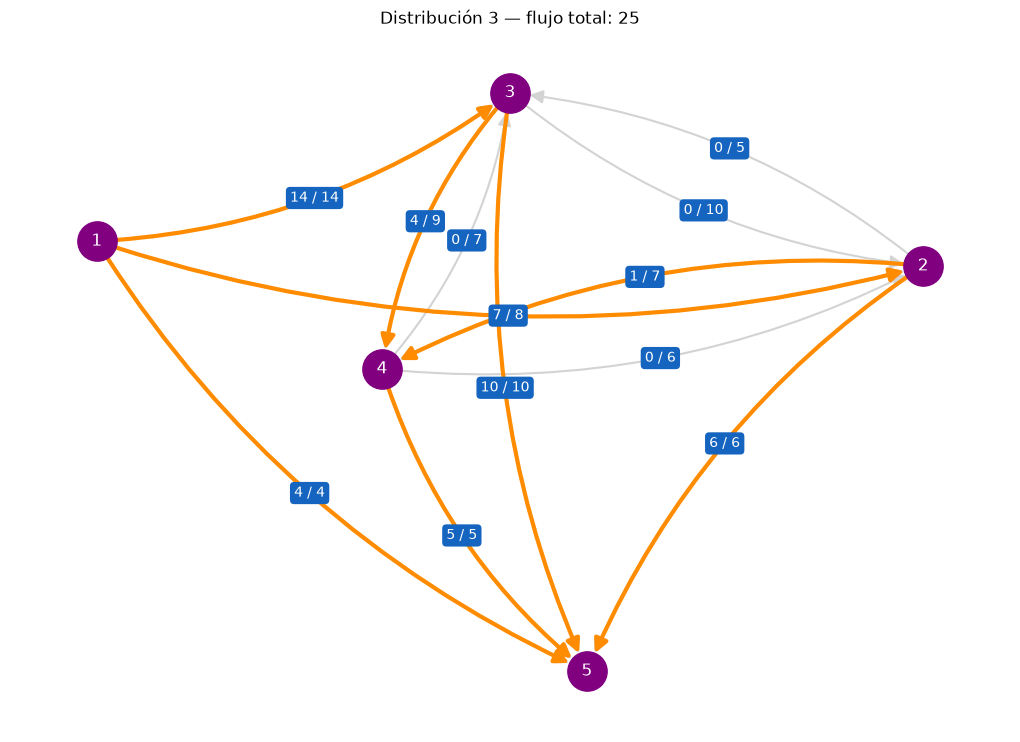

In [23]:
for numero, alternativa in enumerate(soluciones, start=1):
    arcos_con_flujo = [
        (u, v) for u, v in G_flujo.edges()
        if alternativa[u][v] > 0
    ]

    etiquetas = {
        (u, v): f"{alternativa[u][v]} / {G_flujo[u][v]['capacity']}"
        for u, v in G_flujo.edges()
    }

    plt.figure(figsize=(10, 7))

    # Dibujamos la red completa.
    nx.draw(
        G_flujo, pos_flujo,
        with_labels=True,
        node_color="purple",
        font_color="white",
        node_size=800,
        edge_color="lightgray",
        width=1.5,
        arrows=True,
        arrowsize=20,
        connectionstyle="arc3,rad=0.15"
    )

    # Resaltamos el flujo de la distribución actual.
    nx.draw_networkx_edges(
        G_flujo, pos_flujo,
        edgelist=arcos_con_flujo,
        edge_color="darkorange",
        width=3,
        node_size=800,
        arrows=True,
        arrowsize=20,
        connectionstyle="arc3,rad=0.15"
    )

    nx.draw_networkx_edge_labels(
        G_flujo, pos_flujo,
        edge_labels=etiquetas,
        font_color="white",
        bbox={
            "facecolor": "#1565C0",
            "edgecolor": "none",
            "boxstyle": "round,pad=0.3"
        },
        node_size=800,
        connectionstyle="arc3,rad=0.15",
        rotate=False
    )

    valor = sum(alternativa[1].values())
    plt.title(f"Distribución {numero} — flujo total: {valor}")
    plt.show()
    

### <font color="#7B1FA2"><b>3.8. Resultado final</b></font>

| <font color="#1565C0"><b>Resultado</b></font> | <font color="#2E7D32"><b>Conclusión</b></font> |
|---|---|
| **Flujo máximo** | $F^*=25$. |
| **Capacidad del corte mínimo** | $c(S,R)=25$. |
| **Distribución óptima** | No es única. |
| **Conjunto de soluciones reales** | Está caracterizado por la tabla y las restricciones de **3.7**. |

#### <font color="#00838F"><b>¿Por qué existen infinitas soluciones?</b></font>

Podemos elegir:

$$
7\leq a\leq8,\qquad b=d=e=0,\qquad c=a-6.
$$

Entonces:

$$
f_{32}=0,\qquad f_{34}=11-a,
$$

y se cumplen todas las restricciones de **3.7**. Para cualquier valor de $a$ en ese intervalo, el flujo total es:

$$
F=a+(21-a)+4=25.
$$

Como distintos valores de $a$ producen distintos flujos en el arco $1\to2$, obtenemos **infinitas distribuciones óptimas**.

> <font color="#2E7D32"><b>El flujo máximo es de 25 unidades. Su valor es único, pero existen infinitas distribuciones reales que lo alcanzan.</b></font>

### <font color="#7B1FA2"><b>3.9. Documentación de los comandos</b></font>

| <font color="#1565C0"><b>Comando o expresión</b></font> | <font color="#1565C0"><b>Función en el tutorial</b></font> |
|:---|:---|
| `nx.DiGraph()` | Crear la red dirigida. |
| `G_flujo.add_weighted_edges_from(..., weight="capacity")` | Registrar los arcos y guardar sus capacidades en `capacity`. |
| `from networkx.algorithms.flow import edmonds_karp` | Importar el algoritmo de caminos aumentantes. |
| `nx.maximum_flow(G_flujo, 1, 5, ...)` | Devolver el valor máximo y un diccionario con una distribución óptima. |
| `flow_func=edmonds_karp` | Elegir explícitamente Edmonds–Karp. |
| `capacity="capacity"` | Indicar el atributo que contiene las capacidades. |
| `flujo[u][v]` | Consultar el flujo asignado al arco $u\to v$. |
| `G_flujo.edges()` | Recorrer los arcos de la red. |
| `G_flujo.number_of_nodes()` / `G_flujo.number_of_edges()` | Consultar el número de nodos y arcos. |
| `G_flujo.predecessors(nodo)` / `G_flujo.successors(nodo)` | Consultar los nodos con arcos entrantes o salientes. |
| `nx.minimum_cut(G_flujo, 1, 5, ...)` | Devolver la capacidad de un corte mínimo y su partición de nodos. |
| `nx.spring_layout()` | Calcular las posiciones del dibujo. |
| `nx.get_edge_attributes(G_flujo, "capacity")` | Obtener las capacidades en un diccionario. |
| `nx.draw()` / `nx.draw_networkx_edges()` | Dibujar la red y resaltar los arcos con flujo positivo. |
| `nx.draw_networkx_edge_labels()` | Mostrar capacidades o etiquetas de flujo / capacidad. |
| `all(...)` / `sum(...)` | Comprobar todas las condiciones y sumar los flujos. |
| `sorted()` / `enumerate(..., start=1)` | Ordenar los nodos mostrados y numerar los ejemplos. |
| `soluciones.append(alternativa)` | Agregar una distribución a la lista de ejemplos. |
| `plt.figure()` / `plt.title()` / `plt.show()` | Crear, titular y mostrar cada figura. |

#### <font color="#00838F"><b>Documentación oficial</b></font>

- [Grafos dirigidos: DiGraph](https://networkx.org/documentation/stable/reference/classes/digraph.html)
- [Cálculo del flujo máximo](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.flow.maximum_flow.html)
- [Algoritmo de Edmonds–Karp](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.flow.edmonds_karp.html)
- [Cálculo de un corte mínimo](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.flow.minimum_cut.html)
- [Funciones de representación gráfica](https://networkx.org/documentation/stable/reference/drawing.html)